### Sequence Graph Demostration for Navigation

In [91]:
from resource_io import *
import ipywidgets as widgets
from IPython.display import display, Image, clear_output
from shapely.geometry import Point, Polygon



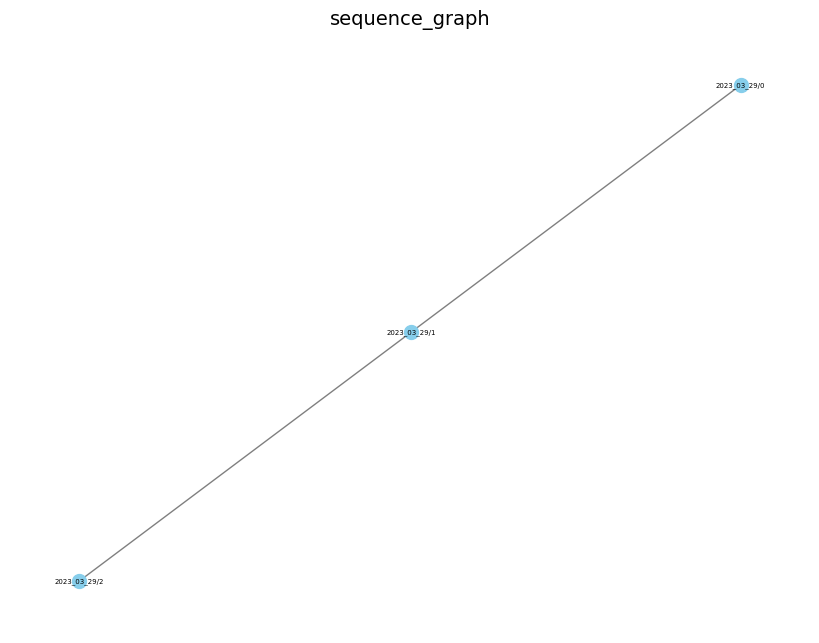

In [92]:
sequence_graph = load_sequence_graph('/lab/kiran/navisim-1/assets/sequence_graph.gpickle')
plot_seq_graph(sequence_graph, out_path='/lab/kiran/navisim-1/assets')

In [93]:
sectors = get_sequence(sequence_graph)
# sectors

In [94]:
seq_id = list(sectors.keys())[1]
# Set up your widgets
text_box = widgets.Text(
    placeholder='Enter direction : (W,A,S,D)',
    description='Direction:',
    continuous_update=False
)
output = widgets.Output()
sector_id = 0
global_pos = None
elevation_map = global_pos
occupancy_map = None

def check_coordinate(boundary, coo):
    x, y = coo
    minx, miny, maxx, maxy = polygon.bounds
    if boundary.covers(Point(x, y)):
        return 0
    
    centroid = polygon.centroid
    cx, cy = centroid.x, centroid.y
    if x < cx:
        return -1
    elif x > cx:
        return 1

    return 

def get_x_at_y(polygon, y0, epsilon=1e-8):
    x_coords = []
    coords = list(polygon.exterior.coords)

    for i in range(len(coords) - 1):
        (x1, y1), (x2, y2) = coords[i], coords[i + 1]

        # Exact horizontal match
        if abs(y1 - y2) < epsilon and abs(y1 - y0) < epsilon:
            x_coords.extend([x1, x2])
            continue

        # Interpolate only when crossing y0
        if (y1 - y0) * (y2 - y0) < 0:
            t = (y0 - y1) / (y2 - y1)
            x = x1 + t * (x2 - x1)
            pt = Point(x, y0)
            if polygon.boundary.contains(pt) or polygon.boundary.touches(pt):
                x_coords.append(x)

        # Endpoints exactly on y0
        elif abs(y1 - y0) < epsilon:
            pt = Point(x1, y1)
            if polygon.boundary.touches(pt):
                x_coords.append(x1)
        elif abs(y2 - y0) < epsilon:
            pt = Point(x2, y2)
            if polygon.boundary.touches(pt):
                x_coords.append(x2)

    if not x_coords:
        # Fallback: return full x extent of polygon
        xs = [pt[0] for pt in polygon.exterior.coords]
        return [min(xs), max(xs)]

    print(sorted(set(x_coords)))
    return sorted(set(x_coords))

def update_coordinate(direction, coordinate):
    x, y = coordinate

    # move left
    if direction == 'A':
        return (x - 4, y)
    # move right
    elif direction == 'D':
        return (x + 4, y)
    
    # move up
    elif direction == 'W':
        return (x, y + 4)
    
    # move down
    elif direction == 'S':
        return (x, y - 4)
    return (x, y)



def handle_submit(change):
    global sector_id, global_pos, elevation_map, occupancy_map, polygon

    try:
        direction = change["new"]
        with output:
            if not direction:
                return

            clear_output(wait=True)

            # Step 1: Update coordinate based on direction
            if global_pos is None:
                # Initialize in center
                elevation_map = get_elevation_map(seq_id, str(sector_id))
                occupancy_map = get_occupancy_map(seq_id, str(sector_id))
                polygon = get_polygon(seq_id, str(sector_id))
                global_pos = (elevation_map.shape[1] // 2, elevation_map.shape[0] // 2)
            else:
                global_pos = update_coordinate(direction, global_pos)

                # Step 2: Fetch current sector polygon and check position
                polygon = get_polygon(seq_id, str(sector_id))
                check = check_coordinate(polygon, global_pos)
                print("check", check)

                if check != 0:
                    # Step 3: update sector
                    sector_id = max(0, sector_id + check)

                    # Step 4: fetch new maps from new sector
                    elevation_map = get_elevation_map(seq_id, str(sector_id))
                    occupancy_map = get_occupancy_map(seq_id, str(sector_id))
                    polygon = get_polygon(seq_id, str(sector_id))

                    # Step 5: adjust coordinate to be just inside new polygon
                    x_candidates = get_x_at_y(polygon, global_pos[1])
                    print("x_candidates", x_candidates)

                    if x_candidates:
                        if check == 1:  # moving left to right
                            global_pos = (int(x_candidates[0]) + 1, global_pos[1])
                        elif check == -1:  # moving right to left
                            global_pos = (int(x_candidates[-1]) - 1, global_pos[1])

                else:
                    # Still in bounds → update map normally
                    elevation_map = get_elevation_map(seq_id, str(sector_id))
                    occupancy_map = get_occupancy_map(seq_id, str(sector_id))

            # Step 6: Plot everything using latest map and position
            plot_maps(elevation_map, occupancy_map, polygon, global_pos)

    except Exception as e:
        with output:
            clear_output(wait=True)
            print(f"Error: {e}")
    finally:
        text_box.value = ""


text_box.observe(handle_submit, names='value')

In [95]:
display(text_box, output)

Text(value='', continuous_update=False, description='Direction:', placeholder='Enter direction : (W,A,S,D)')

Output()